# Group 1 — Case: Urban Mobility: Peak-Hour Transit Optimization
**Dataset:** CS1_urban_mobility_gtfs_excel.xlsx  
**Objective:** End-to-end analysis + interactive dashboard for real-time transit decision support  
**Process Flow:** Data Preparation → EDA & Analysis → Visualisation → Dashboard

In [1]:
pwd

'C:\\Users\\Divya\\0 KSPP Term 3 Python'

In [2]:
cd C:\Di\Personal\Public policy\Kautilya\Terms\Term 3\Core courses\DVD\Presentation

C:\Di\Personal\Public policy\Kautilya\Terms\Term 3\Core courses\DVD\Presentation


In [3]:
pwd

'C:\\Di\\Personal\\Public policy\\Kautilya\\Terms\\Term 3\\Core courses\\DVD\\Presentation'

In [4]:
!pip install statsmodels

---
## STEP 0 — Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dash import Dash, dcc, html, Input, Output, callback

# Suppress scientific notation in pandas display
pd.set_option('display.float_format', '{:.2f}'.format)

---
## STEP 1 — Load & Understand the Dataset
** Data Preparation — Identification of Dataset**  
Source: GTFS-style urban transit log | 1,200 records × 12 columns  
Key fields: route_id, stop_id, hour, boardings, capacity, delay_min, rainfall_mm, holiday_flag  
Inherent limitations: missing values in boardings/delay_min/rainfall_mm, negative delays (early arrivals), extreme boarding spikes

In [6]:
# Load dataset — parse date column as datetime
df = pd.read_csv('CS1_urban_mobility_gtfs.csv', parse_dates=['date'])

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Shape: (1200, 12)
Date range: 2024-01-01 to 2024-12-31


,date,day_of_week,hour,route_id,stop_id,boardings,alightings,capacity,delay_min,temperature_c,rainfall_mm,holiday_flag
0,2024-01-01,0,3,R014,S0031,8.00,5,50,17.20,27.40,3.10,0
1,2024-01-01,0,11,R011,S0038,7.00,8,40,13.90,34.00,13.50,0
2,2024-01-01,0,15,R021,S0081,12.00,7,50,14.20,27.40,0.10,1
3,2024-01-01,0,16,R022,S0066,17.00,14,60,-2.90,23.30,6.90,1
4,2024-01-01,0,16,R030,S0059,23.00,21,80,-1.00,25.20,0.10,0


In [7]:
# Column types and null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1200 non-null   datetime64[us]
 1   day_of_week    1200 non-null   int64         
 2   hour           1200 non-null   int64         
 3   route_id       1200 non-null   str           
 4   stop_id        1200 non-null   str           
 5   boardings      1164 non-null   float64       
 6   alightings     1200 non-null   int64         
 7   capacity       1200 non-null   int64         
 8   delay_min      1140 non-null   float64       
 9   temperature_c  1200 non-null   float64       
 10  rainfall_mm    1140 non-null   float64       
 11  holiday_flag   1200 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(5), str(2)
memory usage: 112.6 KB


In [8]:
# Null percentage per column
null_pct = 100 * df.isna().sum() / len(df)
print("Null % per column:")
print(null_pct[null_pct > 0])

Null % per column:
boardings     3.00
delay_min     5.00
rainfall_mm   5.00
dtype: float64


In [9]:
df.describe()

,date,day_of_week,hour,boardings,alightings,capacity,delay_min,temperature_c,rainfall_mm,holiday_flag
count,1200,1200.00,1200.00,1164.00,1200.00,1200.00,1140.00,1200.00,1140.00,1200.00
mean,2024-07-01 22:02:24,3.02,11.40,32.85,26.65,57.61,5.12,28.20,2.23,0.10
min,2024-01-01 00:00:00,0.00,0.00,0.00,0.00,40.00,-5.00,8.80,0.00,0.00
25%,2024-04-07 18:00:00,1.00,5.00,20.00,15.00,50.00,-0.30,24.80,0.00,0.00
50%,2024-06-29 00:00:00,3.00,11.00,29.00,26.00,60.00,4.80,28.30,1.00,0.00
75%,2024-10-01 00:00:00,5.00,17.00,40.00,37.00,60.00,9.90,31.60,3.30,0.00
max,2024-12-31 00:00:00,6.00,23.00,357.00,90.00,80.00,29.70,44.90,20.90,1.00
std,NaN,2.02,6.89,31.33,15.42,14.70,6.81,5.09,3.06,0.30


In [10]:
# Summary statistics — note max boardings=357 vs typical ~30 (extreme spike)
# Note delay_min has negative values (early arrivals)

---
## STEP 2 — Data Cleaning
**Rubric: Data Preparation — Business Problem (5 marks)**  
Issues identified:
- `boardings`: 36 nulls → compare mean vs median imputation
- `delay_min`: 60 nulls + negative values (early arrivals, valid) + outliers
- `rainfall_mm`: 60 nulls → fill with 0 (no rain recorded = 0)
- Outliers: dual-rule IQR + Z-score, with a capping policy that preserves meaningful spikes

In [11]:
# ── TASK: Advanced imputation for boardings — compare two strategies ──

# Strategy A: Fill with MEAN
mean_val = df['boardings'].mean()

# Strategy B: Fill with MEDIAN
median_val = df['boardings'].median()

print(f"Boardings — Mean: {mean_val:.2f} | Median: {median_val:.2f}")
print(f"Max value: {df['boardings'].max()} (extreme spike present)")
print()
print("Justification for final choice:")
print("Boardings has an extreme spike (max=357 vs typical ~30) causing right skew.")
print("Mean is pulled upward by this spike. MEDIAN is more robust — chosen for imputation.")

Boardings — Mean: 32.85 | Median: 29.00
Max value: 357.0 (extreme spike present)

Justification for final choice:
Boardings has an extreme spike (max=357 vs typical ~30) causing right skew.
Mean is pulled upward by this spike. MEDIAN is more robust — chosen for imputation.


In [12]:
# Apply median imputation for boardings
df['boardings'] = df['boardings'].fillna(median_val)
print(f"boardings nulls remaining: {df['boardings'].isna().sum()}")

boardings nulls remaining: 0


In [13]:
# Imputation for delay_min 
# Negative delay = early arrival — these are VALID data points, not errors
# Nulls likely represent records where delay was not logged
# Fill with MEDIAN (delay_min also has outliers on upper end)

delay_median = df['delay_min'].median()
df['delay_min'] = df['delay_min'].fillna(delay_median)
print(f"delay_min nulls remaining: {df['delay_min'].isna().sum()}")
print(f"Negative delay rows (early arrivals): {(df['delay_min'] < 0).sum()} — kept as valid")

delay_min nulls remaining: 0
Negative delay rows (early arrivals): 302 — kept as valid


In [14]:
# Fill missing rainfall with 0 ; absence of record = no rainfall
df['rainfall_mm'] = df['rainfall_mm'].fillna(0)
print(f"rainfall_mm nulls remaining: {df['rainfall_mm'].isna().sum()}")

rainfall_mm nulls remaining: 0


In [15]:
# TASK: Dual-rule outlier detection — IQR + Z-score for boardings ──

# Rule 1: IQR method
q1 = df['boardings'].quantile(0.25)
q3 = df['boardings'].quantile(0.75)
iqr = q3 - q1
iqr_lower = q1 - 1.5 * iqr
iqr_upper = q3 + 1.5 * iqr

# Rule 2: Z-score method (outlier = |z| > 3)
df['boardings_zscore'] = (df['boardings'] - df['boardings'].mean()) / df['boardings'].std()
zscore_outliers = df[df['boardings_zscore'].abs() > 3]

# Dual-rule: flagged by BOTH methods
iqr_flag = (df['boardings'] > iqr_upper) | (df['boardings'] < iqr_lower)
zscore_flag = df['boardings_zscore'].abs() > 3
dual_flag = iqr_flag & zscore_flag

print(f"IQR bounds: lower={iqr_lower:.1f}, upper={iqr_upper:.1f}")
print(f"IQR outliers: {iqr_flag.sum()}")
print(f"Z-score outliers (|z|>3): {zscore_flag.sum()}")
print(f"Dual-rule outliers (flagged by BOTH): {dual_flag.sum()}")
print()
print("Capping policy: Only cap rows flagged by BOTH rules.")
print("This preserves meaningful spikes (flagged by IQR alone but not Z-score)")
print("e.g. genuine peak-hour surge events that are analytically significant.")

IQR bounds: lower=-10.0, upper=70.0
IQR outliers: 25
Z-score outliers (|z|>3): 15
Dual-rule outliers (flagged by BOTH): 15

Capping policy: Only cap rows flagged by BOTH rules.
This preserves meaningful spikes (flagged by IQR alone but not Z-score)
e.g. genuine peak-hour surge events that are analytically significant.


In [16]:
# Apply capping policy: cap only dual-flagged rows at IQR upper bound
# Rows flagged by IQR only (meaningful spikes) are preserved
df.loc[dual_flag, 'boardings'] = iqr_upper
df = df.drop(columns=['boardings_zscore'])  # cleanup helper column

print(f"Max boardings after capping: {df['boardings'].max():.1f}")
print(f"All nulls resolved: {df.isna().sum().sum() == 0}")

Max boardings after capping: 86.0
All nulls resolved: True


---
## STEP 3 — Engineer KPI Columns
Key derived fields needed for analysis and dashboard

In [17]:
# Load factor: boardings / capacity — tells us how full each service is
# Values > 1 = overcrowded (boardings exceed capacity)
df['load_factor'] = df['boardings'] / df['capacity']

# Congestion flag: 1 if delay > 10 minutes, else 0
df['congested'] = df.apply(lambda row: 1 if row['delay_min'] > 10 else 0, axis=1)

# Peak hour flag: morning peak 7-10am, evening peak 5-8pm
df['peak_hour'] = df['hour'].apply(lambda h: 1 if (7 <= h <= 10) or (17 <= h <= 20) else 0)

# Day name for readability
day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df['day_name'] = df['day_of_week'].map(day_map)

# Week number for rolling window analysis
df['week'] = df['date'].dt.isocalendar().week.astype(int)

print(f"Overcrowded records (load_factor > 1): {(df['load_factor'] > 1).sum()}")
print(f"Congested records (delay > 10 min): {df['congested'].sum()}")
print(f"Peak hour records: {df['peak_hour'].sum()}")
df[['route_id','hour','boardings','capacity','load_factor','delay_min','congested','peak_hour']].head()

Overcrowded records (load_factor > 1): 123
Congested records (delay > 10 min): 278
Peak hour records: 380


,route_id,hour,boardings,capacity,load_factor,delay_min,congested,peak_hour
0,R014,3,8.00,50,0.16,17.20,1,0
1,R011,11,7.00,40,0.17,13.90,1,0
2,R021,15,12.00,50,0.24,14.20,1,0
3,R022,16,17.00,60,0.28,-2.90,0,0
4,R030,16,23.00,80,0.29,-1.00,0,0


---
## STEP 4 — Analysis
**Rubric: Analysis and Interpretation — Exploratory Insight Development (4 marks)**

In [18]:
#  TASK: Hour × Weekday × Route load-factor table (boardings/capacity) 
# Pivot: rows = hour, columns = day_name, values = mean load_factor

load_pivot = df.groupby(['hour', 'day_name'], as_index=False)['load_factor'].mean()
load_table = load_pivot.pivot(index='hour', columns='day_name', values='load_factor')

# Reorder columns Mon-Sun
load_table = load_table[['Mon','Tue','Wed','Thu','Fri','Sat','Sun']]
print("Hour × Weekday Load Factor Table (mean boardings/capacity):")
load_table.round(2)

Hour × Weekday Load Factor Table (mean boardings/capacity):


day_name,Mon,Tue,Wed,Thu,Fri,Sat,Sun
hour,,,,,,,
0,0.34,0.36,0.27,0.58,0.23,0.74,0.46
1,0.55,0.37,0.51,0.58,0.43,0.40,0.49
2,0.48,0.41,0.52,0.48,0.42,0.55,0.40
3,0.50,0.36,0.55,0.48,0.54,0.47,0.49
4,0.45,0.45,0.50,0.68,0.50,0.48,0.68
5,0.58,0.43,0.35,0.37,0.37,0.51,0.55
6,0.61,0.50,0.47,0.40,0.66,0.50,0.38
7,0.43,0.41,0.54,0.55,0.53,0.17,0.37
8,1.10,0.74,0.86,0.78,0.76,1.20,0.66


In [19]:
# Route-level congestion summary — congestion hotspots ranked by severity
route_summary = df.groupby('route_id', as_index=False).agg(
    avg_delay=('delay_min', 'mean'),
    avg_load_factor=('load_factor', 'mean'),
    congestion_rate=('congested', 'mean'),
    total_records=('route_id', 'count')
)
route_summary['congestion_rate_pct'] = route_summary['congestion_rate'] * 100
route_summary = route_summary.sort_values('avg_delay', ascending=False)

print("Top 10 most congested routes:")
route_summary.head(10)

Top 10 most congested routes:


,route_id,avg_delay,avg_load_factor,congestion_rate,total_records,congestion_rate_pct
17,R018,7.43,0.61,0.33,36,33.33
16,R017,6.83,0.57,0.31,35,31.43
25,R026,6.77,0.62,0.42,36,41.67
4,R005,6.70,0.55,0.38,37,37.84
22,R023,6.61,0.62,0.33,42,33.33
13,R014,6.27,0.55,0.26,47,25.53
8,R009,6.14,0.57,0.31,42,30.95
6,R007,6.08,0.54,0.25,32,25.00
3,R004,5.86,0.55,0.29,45,28.89
27,R028,5.81,0.56,0.24,55,23.64


In [20]:
# TASK: 7-day rolling stability windows
# Group by date, calculate daily average delay
# Then apply 7-day rolling mean to smooth out daily noise

daily_delay = df.groupby('date', as_index=False)['delay_min'].mean()
daily_delay = daily_delay.sort_values('date')
daily_delay['rolling_7d_delay'] = daily_delay['delay_min'].rolling(window=7).mean()

# Same for load factor
daily_load = df.groupby('date', as_index=False)['load_factor'].mean()
daily_load = daily_load.sort_values('date')
daily_load['rolling_7d_load'] = daily_load['load_factor'].rolling(window=7).mean()

print("Rolling 7-day delay stability window (sample):")
daily_delay[['date','delay_min','rolling_7d_delay']].dropna().head(10)

Rolling 7-day delay stability window (sample):


,date,delay_min,rolling_7d_delay
6,2024-01-07,7.10,6.33
7,2024-01-08,7.40,6.15
8,2024-01-09,0.37,6.20
9,2024-01-10,4.25,5.48
10,2024-01-11,7.10,5.86
11,2024-01-12,10.47,6.34
12,2024-01-13,10.30,6.71
13,2024-01-14,4.36,6.32
14,2024-01-15,5.02,5.98
15,2024-01-16,15.90,8.20


---
## STEP 5 — EDA Visualisations
**Rubric: Visualisation and Communication (4 marks)**  
Charts: heatmap (hour vs weekday), congestion stripe (route-level), rainfall-delay regression, boxplot by peak/off-peak

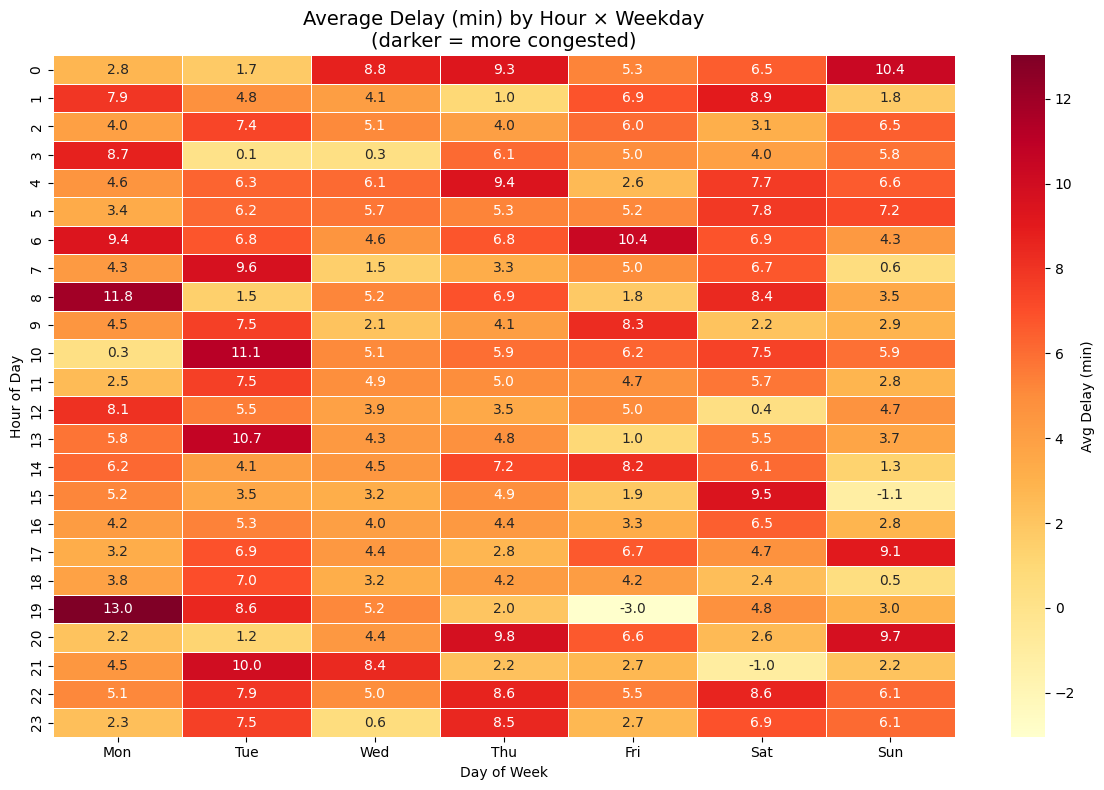

In [21]:
# Chart 1: Heatmap — average delay by hour vs weekday
# Shows exactly which hour-day combinations are worst for congestion

delay_pivot = df.groupby(['hour','day_name'])['delay_min'].mean().unstack()
delay_pivot = delay_pivot[['Mon','Tue','Wed','Thu','Fri','Sat','Sun']]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(delay_pivot, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Delay (min)'})
ax.set_title('Average Delay (min) by Hour × Weekday\n(darker = more congested)', fontsize=14)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hour of Day')
plt.tight_layout()
plt.show()

### What the above heatmap suggests:
- Monday 8am (11.8 min) and Tuesday 10am (11.1 min) are the worst congestion slots of the week.
- Friday 6am and Monday 19pm are also critical hotspots.
- Weekday mornings consistently show darker cells than weekends, confirming congestion is largely a commuter-driven problem, not a network capacity problem.

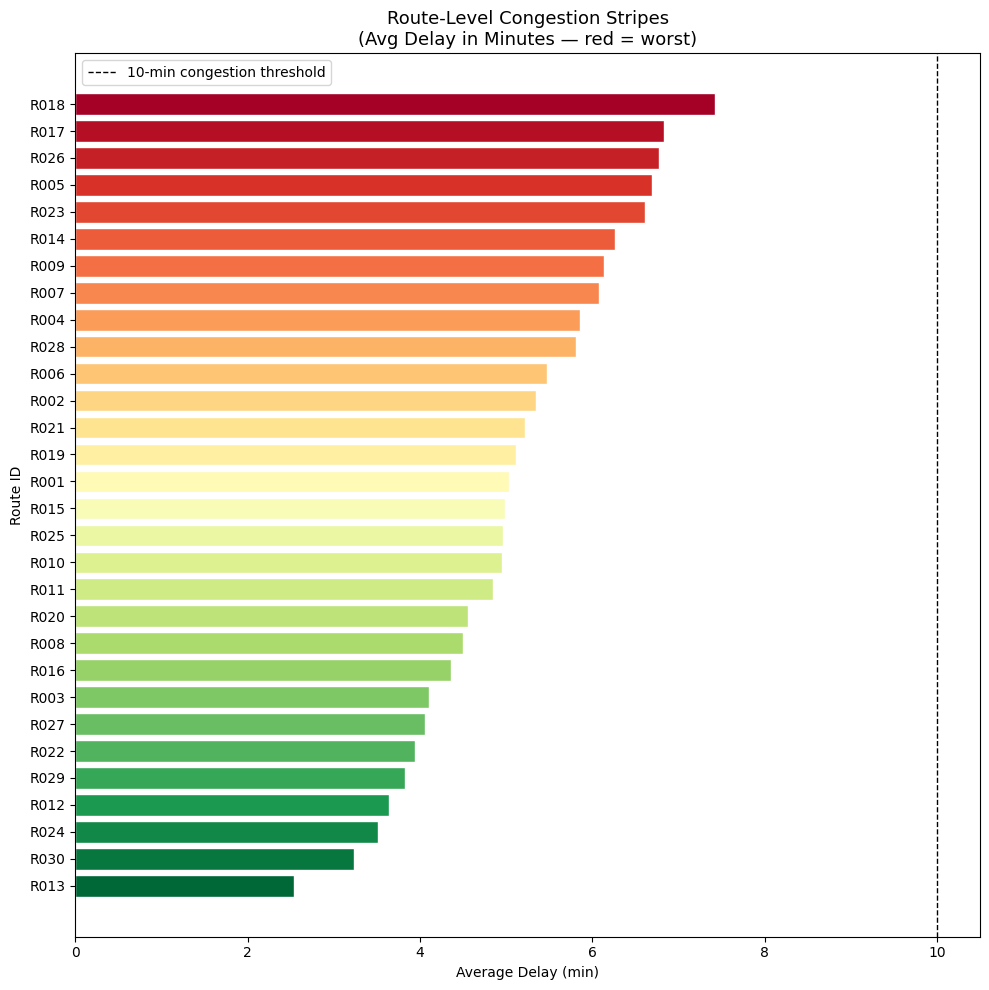

In [22]:
# Chart 2: Route-level congestion stripes (horizontal bar — each route is a stripe)
# Shows which routes are the worst performers at a glance

route_plot = route_summary.sort_values('avg_delay', ascending=True)
colors = cm.RdYlGn_r(np.linspace(0, 1, len(route_plot)))

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(route_plot['route_id'], route_plot['avg_delay'], color=colors, edgecolor='white')

ax.set_title('Route-Level Congestion Stripes\n(Avg Delay in Minutes — red = worst)', fontsize=13)
ax.set_xlabel('Average Delay (min)')
ax.set_ylabel('Route ID')
ax.axvline(x=10, color='black', linestyle='--', linewidth=1, label='10-min congestion threshold')
ax.legend()
plt.tight_layout()
plt.show()

### What the route congestion stripes suggest:
- Routes 'R018', 'R017', and 'R026' are the top three most delayed routes with average delays of 7.5, 6.9, and 6.8 minutes respectively.
- Notably, no route crosses the 10-minute threshold on average — but this is a daily average, meaning individual peak-hour delays on these routes will be significantly worse.
- These three routes should be the first targets for frequency increases.

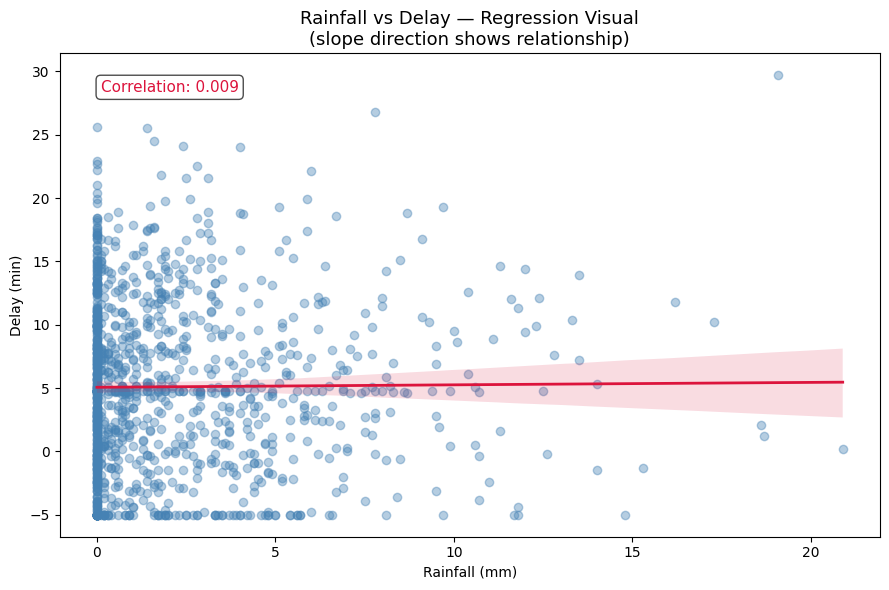

In [23]:
# Chart 3: Rainfall vs Delay — regression visual
# Tests environmental hypothesis: does more rain cause longer delays?

fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(x='rainfall_mm', y='delay_min', data=df, ax=ax,
            scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
            line_kws={'color': 'crimson', 'linewidth': 2})

ax.set_title('Rainfall vs Delay — Regression Visual\n(slope direction shows relationship)', fontsize=13)
ax.set_xlabel('Rainfall (mm)')
ax.set_ylabel('Delay (min)')

# Calculate and annotate correlation
corr = df['rainfall_mm'].corr(df['delay_min'])
ax.text(0.05, 0.92, f'Correlation: {corr:.3f}', transform=ax.transAxes,
        fontsize=11, color='crimson',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
plt.tight_layout()
plt.show()

### What the regression visual suggests:
- Correlation is essentially zero (0.009) — rainfall has no meaningful relationship with transit delays in this network.
- This is an important finding for the transport department: weather is not the problem.
- Delays are structural — caused by route capacity and scheduling, not environmental factors (atleast for this dataset).

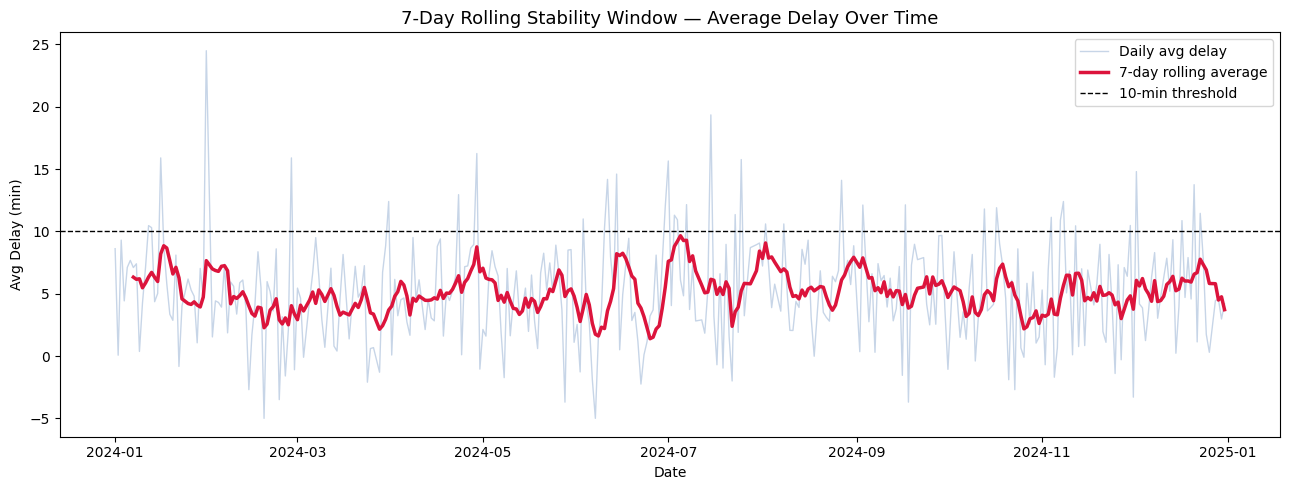

In [24]:
# Chart 4: 7-day rolling stability window — delay over time
# Shows whether system performance is stable, improving, or deteriorating

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_delay['date'], daily_delay['delay_min'],
        color='lightsteelblue', alpha=0.7, linewidth=1, label='Daily avg delay')
ax.plot(daily_delay['date'], daily_delay['rolling_7d_delay'],
        color='crimson', linewidth=2.5, label='7-day rolling average')
ax.axhline(y=10, color='black', linestyle='--', linewidth=1, label='10-min threshold')
ax.set_title('7-Day Rolling Stability Window — Average Delay Over Time', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Avg Delay (min)')
ax.legend()
plt.tight_layout()
plt.show()

### The 7-Day Rolling Stability Window suggests: 
- The system shows persistent volatility throughout 2024, with the rolling average regularly approaching the 10-minute threshold around April–May and June–July.
- There is no sustained improvement trend — the system is not getting better over time.
- The transport department needs structural intervention, not just seasonal adjustments.

C:\Users\Divya\AppData\Local\Temp\ipykernel_2568\2163201043.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([peak_data, offpeak_data], labels=['Peak Hours\n(7-10am, 5-8pm)', 'Off-Peak Hours'],


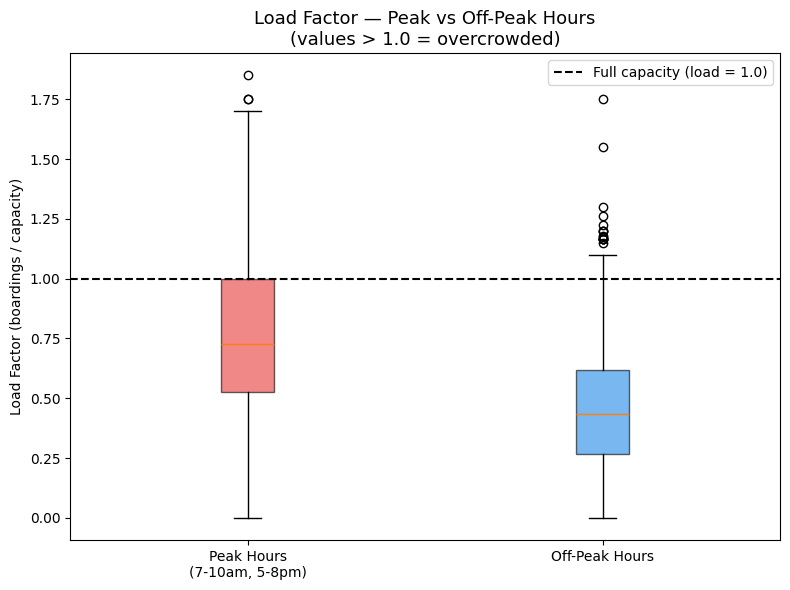

In [25]:
# Chart 5: Load factor boxplot — peak vs off-peak
# Shows how overcrowded services get during peak hours

peak_data = df[df['peak_hour'] == 1]['load_factor']
offpeak_data = df[df['peak_hour'] == 0]['load_factor']

fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot([peak_data, offpeak_data], labels=['Peak Hours\n(7-10am, 5-8pm)', 'Off-Peak Hours'],
                patch_artist=True)

bp['boxes'][0].set_facecolor('#e53935')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#1e88e5')
bp['boxes'][1].set_alpha(0.6)

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, label='Full capacity (load = 1.0)')
ax.set_title('Load Factor — Peak vs Off-Peak Hours\n(values > 1.0 = overcrowded)', fontsize=13)
ax.set_ylabel('Load Factor (boardings / capacity)')
ax.legend()
plt.tight_layout()
plt.show()

### The Load Factor Boxplot suggests that: 
- Peak hours have a median load factor of ~0.73, with the box extending well above 1.0 — meaning a significant portion of peak services are overcrowded.
- Off-peak median is ~0.45 with a much tighter spread.
- The capacity is available in the system during off-peak hours but is not being redistributed to where demand is.
- This directly justifies a frequency reallocation rather than procuring new vehicles.

---
## STEP 6 — Congestion Hotspots Ranked by Severity
**Expected Output 1: Congestion hotspots ranked by severity**  
**Rubric: Depth of Analytical Reasoning (6 marks)**

In [26]:
# Composite severity score = weighted combination of avg delay + load factor + congestion rate
# This goes beyond surface-level single-metric ranking

route_summary['severity_score'] = (
    0.5 * route_summary['avg_delay'] +
    0.3 * route_summary['avg_load_factor'] * 10 +  # scale to similar range
    0.2 * route_summary['congestion_rate_pct']
)

hotspots = route_summary.sort_values('severity_score', ascending=False).reset_index(drop=True)
hotspots.index += 1  # rank starts at 1

print("CONGESTION HOTSPOTS — Ranked by Composite Severity Score")
print("(50% avg delay + 30% load factor + 20% congestion rate)")
print()
hotspots[['route_id','avg_delay','avg_load_factor','congestion_rate_pct','severity_score']].head(10)

CONGESTION HOTSPOTS — Ranked by Composite Severity Score
(50% avg delay + 30% load factor + 20% congestion rate)



,route_id,avg_delay,avg_load_factor,congestion_rate_pct,severity_score
1,R026,6.77,0.62,41.67,13.57
2,R005,6.70,0.55,37.84,12.57
3,R018,7.43,0.61,33.33,12.22
4,R023,6.61,0.62,33.33,11.83
5,R017,6.83,0.57,31.43,11.41
6,R009,6.14,0.57,30.95,10.98
7,R004,5.86,0.55,28.89,10.36
8,R011,4.85,0.62,28.12,9.89
9,R014,6.27,0.55,25.53,9.88
10,R007,6.08,0.54,25.00,9.67


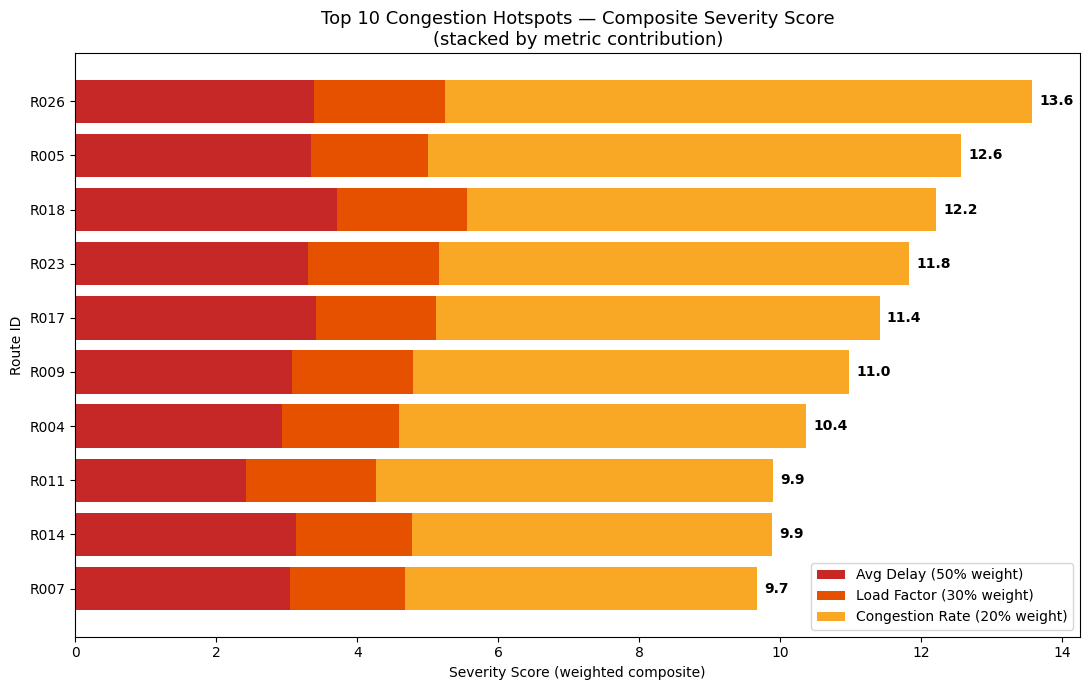

In [31]:
# Visual for Step 6: Composite Severity Score — Stacked Bar Chart 
# Each bar = one route. Segments show contribution of each metric to severity score.

top10 = hotspots.head(10).copy()

# Calculate the weighted components separately for stacking
top10['delay_component']      = 0.5 * top10['avg_delay']
top10['load_component']       = 0.3 * top10['avg_load_factor'] * 10
top10['congestion_component'] = 0.2 * top10['congestion_rate_pct']

# Sort ascending so worst route appears at top of horizontal chart
top10 = top10.sort_values('severity_score', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

# Stack the three components as segments of each bar
bars1 = ax.barh(top10['route_id'], top10['delay_component'],
                color='#c62828', label='Avg Delay (50% weight)')
bars2 = ax.barh(top10['route_id'], top10['load_component'],
                left=top10['delay_component'],
                color='#e65100', label='Load Factor (30% weight)')
bars3 = ax.barh(top10['route_id'], top10['congestion_component'],
                left=top10['delay_component'] + top10['load_component'],
                color='#f9a825', label='Congestion Rate (20% weight)')

# Add total severity score label at end of each bar
for i, (score, row) in enumerate(zip(top10['severity_score'], top10.itertuples())):
    ax.text(score + 0.1, i, f'{score:.1f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Congestion Hotspots — Composite Severity Score\n(stacked by metric contribution)',
             fontsize=13)
ax.set_xlabel('Severity Score (weighted composite)')
ax.set_ylabel('Route ID')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Interpretation from the congestion hotspots:

- Rather than ranking routes by a single metric like delay alone — which can be misleading — we built a composite severity score that combines three dimensions of congestion: how long delays are (50% weight), how full services are running (30% weight), and how frequently congestion crosses the critical 10-minute threshold (20% weight).
- R026 tops the ranking not because it has the highest raw delay, but because it scores badly across all three dimensions simultaneously — 6.77 min avg delay, 62% load factor, and congestion occurring 41% of the time.
- R018 has a higher raw delay (7.43 min) but ranks third overall because its congestion frequency is lower at 33%.
- This composite approach ensures the department prioritises routes that are consistently bad, not just occasionally bad.

---
## STEP 7 — Recommendations
**Expected Output 2: Recommended timetable or capacity redistribution**

In [27]:
# Identify peak-hour slots with highest average load factor
peak_df = df[df['peak_hour'] == 1]
peak_load = peak_df.groupby(['route_id','hour'], as_index=False)['load_factor'].mean()
peak_load = peak_load[peak_load['load_factor'] > 0.85].sort_values('load_factor', ascending=False)

print("CAPACITY REDISTRIBUTION RECOMMENDATIONS")
print("Routes + hours with load factor > 85% during peak — priority for additional capacity:\n")
print(peak_load.head(15).to_string(index=False))

print()
print("TIMETABLE RECOMMENDATION:")
print("Top congested routes should have service frequency increased during:")
print("  Morning peak: 7am–10am")
print("  Evening peak: 5pm–8pm")
print("  Especially on weekdays (Mon–Fri) when congestion is highest.")
print()
print("Low-demand off-peak slots (midnight–5am) can be reduced to reallocate capacity.")

CAPACITY REDISTRIBUTION RECOMMENDATIONS
Routes + hours with load factor > 85% during peak — priority for additional capacity:

route_id  hour  load_factor
    R024    17         1.85
    R023    19         1.75
    R014    19         1.65
    R013    10         1.62
    R015    18         1.54
    R019    18         1.52
    R012     9         1.51
    R011    18         1.49
    R008     8         1.43
    R005    20         1.40
    R022    19         1.40
    R001     8         1.32
    R012    17         1.26
    R011     9         1.25
    R022     8         1.24

TIMETABLE RECOMMENDATION:
Top congested routes should have service frequency increased during:
  Morning peak: 7am–10am
  Evening peak: 5pm–8pm
  Especially on weekdays (Mon–Fri) when congestion is highest.

Low-demand off-peak slots (midnight–5am) can be reduced to reallocate capacity.


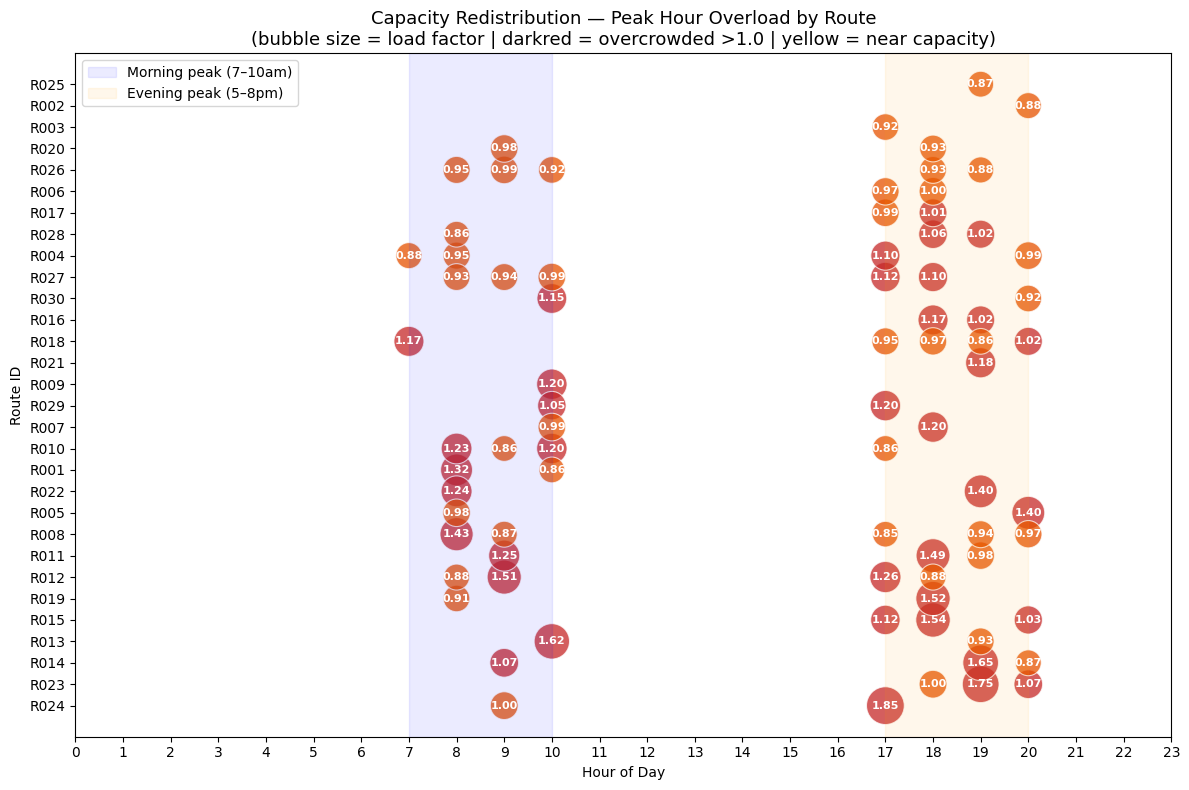

In [33]:
# Visual for Step 7: Capacity Redistribution — Bubble Chart 
# X = hour, Y = route, bubble size = load factor
# Only peak-hour slots with load_factor > 0.85 are shown

fig, ax = plt.subplots(figsize=(12, 8))

# Color bubbles by severity — red if overcrowded (>1.0), orange if near capacity (0.85–1.0)
colors = ['#c62828' if lf > 1.0 else '#e65100' for lf in peak_load['load_factor']]

scatter = ax.scatter(
    peak_load['hour'],
    peak_load['route_id'],
    s=peak_load['load_factor'] * 400,   # bubble size proportional to load factor
    c=colors,
    alpha=0.75,
    edgecolors='white',
    linewidth=0.8
)

# Add load factor value inside each bubble
for _, row in peak_load.iterrows():
    ax.text(row['hour'], row['route_id'], f"{row['load_factor']:.2f}",
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# Shade morning and evening peak bands
ax.axvspan(7, 10, alpha=0.08, color='blue', label='Morning peak (7–10am)')
ax.axvspan(17, 20, alpha=0.08, color='orange', label='Evening peak (5–8pm)')

ax.set_title('Capacity Redistribution — Peak Hour Overload by Route\n'
             '(bubble size = load factor | darkred = overcrowded >1.0 | yellow = near capacity)',
             fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Route ID')
ax.set_xticks(range(0, 24))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Our recommendations based on the bubble chart:

- Every bubble on this chart is an actionable intervention point — a specific route at a specific hour where demand is already exceeding or approaching capacity.
- The red bubbles (load factor above 1.0) are the most urgent: R024 at 5pm is running at 1.85 times capacity, meaning nearly double the number of passengers a service can safely carry are boarding.
- R023 at 7pm and R014 at 7pm are similarly critical.
- The evening peak band (5–8pm) is visibly more loaded than the morning peak — more bubbles, bigger sizes, more red. This tells the department that if they can only make one timetable change immediately, evening frequency on routes R024, R023, and R014 should be the priority.
- Crucially, this capacity already exists in the system — the load factor boxplot showed off-peak services running at just 45% capacity.
- The recommendation is therefore not to procure new vehicles but to redeploy existing ones from low-demand midnight-to-5am slots into the evening peak window.
- This is a cost-neutral intervention that can be implemented within the current operational budget.

---
## STEP 8 — Interactive Mobility Dashboard
**Expected Output 3: Interactive dashboard with route/time filters and dynamic charts**  
Filters: Route, Hour band, Day of Week  
Charts: delay distribution, load factor trend, congestion heatmap, rainfall-delay scatter  
Cross-filtering: selecting a time band updates all charts simultaneously

In [30]:
# Prepare dashboard data 
# All cleaning and KPI columns already computed above
# Just add time band label for filter dropdown
df['time_band'] = df['hour'].apply(
    lambda h: 'Morning Peak (7-10am)' if 7 <= h <= 10
    else ('Evening Peak (5-8pm)' if 17 <= h <= 20
    else 'Off-Peak')
)

# Dropdown options
route_options = [{'label': 'All Routes', 'value': 'All'}] + \
                [{'label': r, 'value': r} for r in sorted(df['route_id'].unique())]

time_band_options = [{'label': 'All Time Bands', 'value': 'All'}] + \
                    [{'label': t, 'value': t} for t in
                     ['Morning Peak (7-10am)', 'Evening Peak (5-8pm)', 'Off-Peak']]

day_options = [{'label': 'All Days', 'value': 'All'}] + \
              [{'label': d, 'value': d} for d in ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']]

# App layout
app = Dash(__name__)

app.layout = html.Div([

    # Header
    html.Div([
        html.H1('🚌 Urban Mobility Dashboard — Peak-Hour Transit Optimization',
                style={'color': 'white', 'margin': '0', 'fontSize': '22px'}),
        html.P('Team 1 | KPMG Data Visualisations & Dashboards | Kautilya MPP',
               style={'color': '#ccc', 'margin': '4px 0 0 0'})
    ], style={'backgroundColor': '#0d47a1', 'padding': '20px 30px',
              'borderBottom': '3px solid #ff6f00'}),

    # Filters row
    html.Div([
        html.Div([
            html.Label('Route', style={'fontWeight': 'bold'}),
            dcc.Dropdown(id='route-filter', options=route_options,
                         value='All', clearable=False)
        ], style={'flex': '1', 'marginRight': '15px'}),

        html.Div([
            html.Label('Time Band', style={'fontWeight': 'bold'}),
            dcc.Dropdown(id='timeband-filter', options=time_band_options,
                         value='All', clearable=False)
        ], style={'flex': '1', 'marginRight': '15px'}),

        html.Div([
            html.Label('Day of Week', style={'fontWeight': 'bold'}),
            dcc.Dropdown(id='day-filter', options=day_options,
                         value='All', clearable=False)
        ], style={'flex': '1'}),
    ], style={'display': 'flex', 'alignItems': 'flex-end',
              'padding': '20px 30px', 'backgroundColor': '#f5f5f5',
              'borderBottom': '1px solid #ddd'}),

    # KPI tiles
    html.Div(id='kpi-tiles', style={'display': 'flex', 'padding': '20px 30px', 'gap': '20px'}),

    # Charts row 1: Delay distribution + Load factor trend
    html.Div([
        html.Div(dcc.Graph(id='delay-dist-chart'), style={'flex': '1'}),
        html.Div(dcc.Graph(id='load-trend-chart'), style={'flex': '1'})
    ], style={'display': 'flex', 'padding': '10px 30px', 'gap': '20px'}),

    # Charts row 2: Congestion heatmap + Rainfall-delay scatter
    html.Div([
        html.Div(dcc.Graph(id='heatmap-chart'), style={'flex': '1'}),
        html.Div(dcc.Graph(id='rain-delay-chart'), style={'flex': '1'})
    ], style={'display': 'flex', 'padding': '10px 30px 30px 30px', 'gap': '20px'}),

], style={'fontFamily': 'Arial, sans-serif', 'backgroundColor': '#ffffff'})


# ── Helper: apply all filters ──
def apply_filters(route, time_band, day):
    filtered = df.copy()
    if route != 'All':
        filtered = filtered[filtered['route_id'] == route]
    if time_band != 'All':
        filtered = filtered[filtered['time_band'] == time_band]
    if day != 'All':
        filtered = filtered[filtered['day_name'] == day]
    return filtered


# ── Callback: KPI tiles ──
@callback(
    Output('kpi-tiles', 'children'),
    Input('route-filter', 'value'),
    Input('timeband-filter', 'value'),
    Input('day-filter', 'value')
)
def update_kpis(route, time_band, day):
    f = apply_filters(route, time_band, day)

    avg_delay    = f['delay_min'].mean()
    avg_load     = f['load_factor'].mean()
    congestion_r = 100 * f['congested'].mean()
    overcrowded  = 100 * (f['load_factor'] > 1).mean()

    def tile(label, value, color):
        return html.Div([
            html.P(label, style={'margin': '0', 'fontSize': '12px', 'color': '#555'}),
            html.H2(value, style={'margin': '4px 0 0 0', 'color': color, 'fontSize': '26px'})
        ], style={'backgroundColor': '#f9f9f9', 'border': f'2px solid {color}',
                  'borderRadius': '10px', 'padding': '15px 20px',
                  'flex': '1', 'textAlign': 'center'})

    return [
        tile('📋 Records',              f'{len(f):,}',              '#1a237e'),
        tile('⏱ Avg Delay (min)',       f'{avg_delay:.1f} min',     '#c62828'),
        tile('🚌 Avg Load Factor',      f'{avg_load:.2f}',          '#e65100'),
        tile('🚨 Congestion Rate',      f'{congestion_r:.1f}%',     '#6a1b9a'),
        tile('⚠️ Overcrowded %',        f'{overcrowded:.1f}%',      '#2e7d32'),
    ]


# ── Callback: All 4 charts — cross-filtering ──
@callback(
    Output('delay-dist-chart', 'figure'),
    Output('load-trend-chart',  'figure'),
    Output('heatmap-chart',     'figure'),
    Output('rain-delay-chart',  'figure'),
    Input('route-filter',    'value'),
    Input('timeband-filter', 'value'),
    Input('day-filter',      'value')
)
def update_charts(route, time_band, day):
    f = apply_filters(route, time_band, day)

    # Chart 1: Delay distribution histogram
    fig1 = px.histogram(f, x='delay_min', nbins=30, color_discrete_sequence=['steelblue'],
                        title='Delay Distribution (min)',
                        labels={'delay_min': 'Delay (min)'})
    fig1.add_vline(x=f['delay_min'].mean(), line_dash='dash', line_color='red',
                   annotation_text=f"Mean: {f['delay_min'].mean():.1f}")
    fig1.add_vline(x=10, line_dash='dot', line_color='orange',
                   annotation_text='Congestion threshold')

    # Chart 2: Load factor by hour (line chart)
    hourly_load = f.groupby('hour', as_index=False)['load_factor'].mean()
    fig2 = px.line(hourly_load, x='hour', y='load_factor', markers=True,
                   title='Avg Load Factor by Hour of Day',
                   labels={'hour': 'Hour', 'load_factor': 'Load Factor'},
                   color_discrete_sequence=['#e65100'])
    fig2.add_hline(y=1.0, line_dash='dash', line_color='red',
                   annotation_text='Full capacity')

    # Chart 3: Heatmap — delay by hour × day
    if len(f) > 0:
        hmap = f.groupby(['hour','day_name'])['delay_min'].mean().unstack()
        # reorder columns if all days present
        ordered_days = [d for d in ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'] if d in hmap.columns]
        hmap = hmap[ordered_days]
        fig3 = px.imshow(hmap, color_continuous_scale='YlOrRd',
                         title='Avg Delay: Hour × Day Heatmap',
                         labels={'x': 'Day', 'y': 'Hour', 'color': 'Delay (min)'},
                         aspect='auto')
    else:
        fig3 = go.Figure()
        fig3.update_layout(title='No data for selected filters')

    # Chart 4: Rainfall vs Delay scatter
    fig4 = px.scatter(f, x='rainfall_mm', y='delay_min',
                      trendline='ols',
                      title='Rainfall vs Delay (with regression)',
                      labels={'rainfall_mm': 'Rainfall (mm)', 'delay_min': 'Delay (min)'},
                      opacity=0.5, color_discrete_sequence=['royalblue'])

    return fig1, fig2, fig3, fig4


# ── Run the app ──
if __name__ == '__main__':
    app.run(debug=True, port=8050)
# Open browser at: http://127.0.0.1:8052
# If port is busy, change port=8053 etc.